# Imports


In [1]:
import tensorflow as tf
print("Dispositivos GPU:", tf.config.list_physical_devices('GPU'))

Dispositivos GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from tensorflow.python.client import device_lib

def get_available_gpus():
    local_device_protos = device_lib.list_local_devices()
    return [x.physical_device_desc for x in local_device_protos if x.device_type == 'GPU']

print(get_available_gpus())

['device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6']


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
from collections import defaultdict
import pickle
import torch
import time

In [4]:
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import multilabel_confusion_matrix, f1_score, classification_report

In [5]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input

In [6]:
from functions import *
import cv2

In [7]:
random.seed(42)
tf.random.set_seed(42)

# Data

In [8]:
path_sessions = "../capturas/capturas_256x256/SesionesCorrectas"

In [9]:

seq_session = {}

for entry in os.listdir(path_sessions):
    entry_path = os.path.join(path_sessions, entry)
    if os.path.isdir(entry_path) and entry.startswith("Session_"):
        image_files = [f for f in os.listdir(entry_path) if f.endswith(".png")]
        image_paths = [os.path.join(entry_path, f) for f in sorted(image_files)]
        seq_session[entry] = image_paths

In [10]:
print(seq_session['Session_001'][:10])

['../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0000.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0001.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0002.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0003.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0004.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0005.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0006.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0007.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0008.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0009.png']


In [11]:
sessions = list(seq_session)
print(sessions)
random.shuffle(sessions)
print(sessions)

['Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007', 'Session_008', 'Session_009', 'Session_010']
['Session_008', 'Session_004', 'Session_003', 'Session_009', 'Session_006', 'Session_007', 'Session_010', 'Session_005', 'Session_001', 'Session_002']


In [12]:
# train test split

train_sess = sessions[:7]
val_sess = sessions[7:8]
test_sess = sessions[8:]

print(f"training sessions: {train_sess}")
print(f"validation sessions: {val_sess}")
print(f"test sessions: {test_sess}")

training sessions: ['Session_008', 'Session_004', 'Session_003', 'Session_009', 'Session_006', 'Session_007', 'Session_010']
validation sessions: ['Session_005']
test sessions: ['Session_001', 'Session_002']


In [13]:
def session_window(sessions, seq_sessions_dic, window_size):
    for session_name in sessions:
        img_paths = seq_sessions_dic[session_name]

        if window_size > len(img_paths):
            print("window_size demasiado grande")
            return
        
        for i in range(len(img_paths) - window_size):
            window_paths = img_paths[i:i+window_size]
            target_path = img_paths[i+window_size]

            yield window_paths, target_path

../capturas/capturas_256x256/SesionesCorrectas\Session_001\capture_0300.png


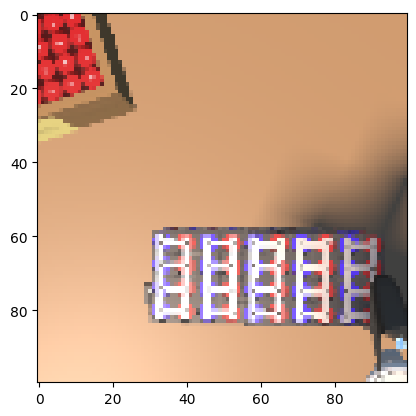

In [14]:
path = seq_session['Session_001'][300]
print(path)

size=(100, 100)
img = tf.io.read_file(path)
img = tf.image.decode_png(img, channels=3)
img = tf.image.resize(img, size)
img = img / 255.0
plt.imshow(img)
plt.show()

In [15]:
def ssim_metric(y_true, y_pred):
    # tf.image.ssim espera que las imágenes estén en rango [0, 1]
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def psnr_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))

*PSNR* (Peak Signal-to-Noise Ratio): mide la relación entre el los detalles nítidos de la imagen y el ruido que introduce la predicción. Se mide en decibelios, cuanto mayor sea el número mejor.  
- valores por encima de 25-30 dB se consideran buenos
  
*SSIM* (Structural Similarity Index): Evalía la imagen en ventanas locales buscando mantener la estructura, el contraste y la textura. Rango de -1 a 1, 1 significa imágenes idénticas.
- Si está por debajo de 0.85, el modelo está emborronando mucho los movimientos o ignorando las piezas nuevas.
- Si sube de 0.92 - 0.95, significa que el modelo está dibujando con muchísima precisión los cambios estructurales

In [16]:
img_size = 100

def load_imgs_for_window(window_paths, target_path):
    window_images = tf.map_fn(lambda x: load_img_ts(x, size=(img_size, img_size)), window_paths, fn_output_signature=tf.float32)
    target_image = load_img_ts(target_path, size=(img_size, img_size))

    return window_images, target_image

def create_ds(sessions_list, seq_session_dic, window_size, batch_size=16):
    dataset = tf.data.Dataset.from_generator(
        lambda: session_window(sessions_list, seq_session_dic, window_size),
        output_signature=(
            tf.TensorSpec(shape=(window_size,), dtype=tf.string), # Rutas de la ventana
            tf.TensorSpec(shape=(), dtype=tf.string)              # Ruta del target
        )
    )

    dataset = dataset.map(load_imgs_for_window, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE) 
    
    return dataset


In [17]:
window_size = 7
batch_size = 8

train_ds = create_ds(train_sess, seq_session, window_size, batch_size)
val_ds = create_ds(val_sess, seq_session, window_size, batch_size)
test_ds = create_ds(test_sess, seq_session, window_size, batch_size)

# Training and testing

## Pipeline

In [21]:
def training_pipeline_ts(model, train_ds, val_ds, test_ds, patience=3, epochs=20, lr=0.005):
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=patience, verbose=1, min_lr=4e-10
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=patience*2, 
        verbose=1, 
        restore_best_weights=True
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.MeanSquaredError(), # probar MeanAbsoluteError()
        metrics=['mae', ssim_metric, psnr_metric]
    )
        
    history = model.fit(
        train_ds, 
        epochs=epochs, 
        validation_data=val_ds, 
        callbacks=[lr_callback, early_stop]
    )

    print("\nEvaluando en Entrenamiento...")
    train_loss, train_mse, train_ssim, train_psnr = model.evaluate(train_ds, verbose=0)
    print("Evaluando en Test...")
    test_loss, test_mse, test_ssim, test_psnr = model.evaluate(test_ds, verbose=0)
    
    return test_mse, train_mse, train_loss, test_loss, train_ssim, test_ssim, train_psnr, test_psnr, history

## CNN + LSTM model

In [22]:
model_00 = Sequential([
   
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        input_shape=(window_size, img_size, img_size, 3)
    ),
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False
    ),
    Conv2D(
        filters=3,
        kernel_size=(3, 3),
        activation="sigmoid",
        padding="same"
    )
])

In [23]:
test_mse, train_mse, train_loss, test_loss, train_ssim, test_ssim, train_psnr, test_psnr, history = training_pipeline_ts(model_00, train_ds, val_ds, test_ds, lr=0.001)

print(f"Test mse: {test_mse}\nTrain mse: {train_mse}")
print(f"Test loss: {test_loss}\nTrain loss: {train_loss}")
print(f"Test ssim: {test_ssim}\nTrain ssim: {train_ssim}")
print(f"Test psnr: {test_psnr}\nTrain loss: {train_psnr}")

Epoch 1/20
355/355 [==============================] - 232s 638ms/step - loss: 0.0084 - mae: 0.0509 - ssim_metric: 0.8644 - psnr_metric: 22.2347 - val_loss: 0.0227 - val_mae: 0.1219 - val_ssim_metric: 0.7714 - val_psnr_metric: 16.4777 - lr: 0.0010
Epoch 2/20
355/355 [==============================] - 231s 652ms/step - loss: 0.0066 - mae: 0.0406 - ssim_metric: 0.8954 - psnr_metric: 23.5862 - val_loss: 0.0064 - val_mae: 0.0392 - val_ssim_metric: 0.9037 - val_psnr_metric: 23.0448 - lr: 0.0010
Epoch 3/20
355/355 [==============================] - 235s 663ms/step - loss: 0.0065 - mae: 0.0390 - ssim_metric: 0.8996 - psnr_metric: 23.8455 - val_loss: 0.0064 - val_mae: 0.0370 - val_ssim_metric: 0.9060 - val_psnr_metric: 23.3059 - lr: 0.0010
Epoch 4/20
355/355 [==============================] - 237s 667ms/step - loss: 0.0064 - mae: 0.0382 - ssim_metric: 0.9020 - psnr_metric: 23.9728 - val_loss: 0.0064 - val_mae: 0.0375 - val_ssim_metric: 0.9088 - val_psnr_metric: 23.2892 - lr: 0.0010
Epoch 5/20
3

1/1 [==============================] - 0s 471ms/step


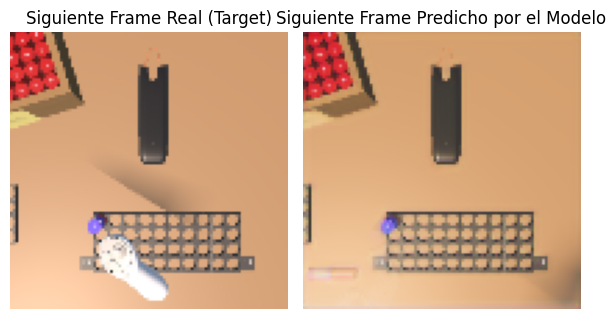

1/1 [==============================] - 0s 41ms/step


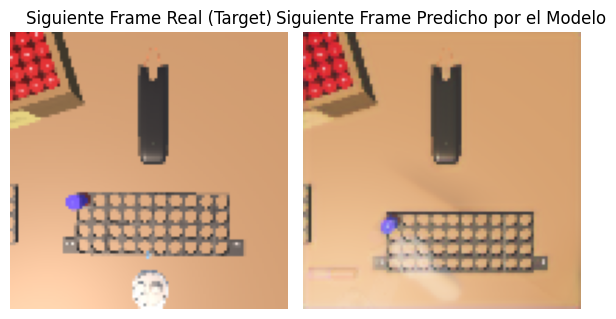

In [ ]:
for i in range():    
    for X_batch, y_batch in test_ds.take(1):
        
        ventana_prueba = X_batch[i]
        imagen_real = y_batch[i]
        
        input_modelo = np.expand_dims(ventana_prueba, axis=0)
        
        prediccion = model_00.predict(input_modelo)
        
        imagen_predicha = prediccion[0]
        
        fig, axes = plt.subplots(1, 2, figsize=(6, 4))
        
        # Imagen Real (Target)
        axes[0].imshow(imagen_real)
        axes[0].set_title("Siguiente Frame Real (Target)")
        axes[0].axis('off')
        
        # Imagen Predicha por el Modelo
        axes[1].imshow(imagen_predicha)
        axes[1].set_title("Siguiente Frame Predicho por el Modelo")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        break